<a href="https://colab.research.google.com/github/JFSS20000/07MIAR04/blob/Actividad_Articulo_C1/C2_ResUnet_JOSE_FERNANDO_SARMIENTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instalar el modelo desde el repositorio original

In [1]:
# Instalar el modelo del repositorio original

!python -m pip install git+https://github.com/JanPalasek/resunet-tensorflow

  Cloning https://github.com/JanPalasek/resunet-tensorflow to /tmp/pip-req-build-iin583l5
  Running command git clone --filter=blob:none --quiet https://github.com/JanPalasek/resunet-tensorflow /tmp/pip-req-build-iin583l5
  Resolved https://github.com/JanPalasek/resunet-tensorflow to commit 9f080caba27441a16697818cb7064839c40223e5
  Preparing metadata (setup.py) ... done
  Created wheel for resunet: filename=resunet-1.1-py3-none-any.whl size=2822 sha256=b62468e4a9b2f3fdf8702dc28435f6c9d947760970594b5a53c33f7213ff30b2
  Stored in directory: /tmp/pip-ephem-wheel-cache-3_u89p9f/wheels/c0/2d/6e/f4e737af24afd540201857bdf3ac8c3149e36c5fba075c4487
Successfully built resunet


## Entrenar el modelo en este proyecto

In [2]:
from resunet import ResUNet
import tensorflow as tf
import tensorflow_datasets as tfds


In [7]:
# 1. DESCARGAR Y PREPARAR EL DATASET (Oxford-IIIT Pet)

def load_image(datapoint):
    # Redimensionar imagen a 128x128 (3 canales RGB)
    img = tf.image.resize(datapoint['image'], (128, 128))
    img = tf.cast(img, tf.float32) / 255.0

    # Redimensionar máscara (viene como 128, 128, 1)
    mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))

    # El dataset tiene etiquetas 1, 2, 3. Convertimos a 0 y 1.
    mask = tf.cast(mask, tf.int32)
    mask -= 1
    mask = tf.where(mask > 0, 1, 0)

    # ELIMINAR DIMENSIÓN EXTRA: De (128, 128, 1) a (128, 128)
    mask = tf.reshape(mask, (128, 128))

    # ONE-HOT: De (128, 128) a (128, 128, 2)
    mask = tf.one_hot(mask, depth=2)

    return img, mask

dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True)

BATCH_SIZE = 32

train_batches = (
    dataset['train']
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_batches = (
    dataset['test']
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
)

In [8]:
# 2. CONFIGURAR EL MODELO RESUNET
#### create model for inputs of sizes (128, 128, 1) for semantic segmentation into 2 classes
#### architecture will have 16 filters in the root and the depth of 3 blocks
#### model = ResUNet(input_shape=(128, 128, 1), classes=2, filters_root=16, depth=3)

# Cambiamos input_shape a (128, 128, 3) porque el dataset es a color (RGB)
model = ResUNet(input_shape=(128, 128, 3), classes=2, filters_root=16, depth=3)

# compile the model
# categorical crossentropy is the preferred loss function
##model.compile(loss="categorical_crossentropy", optimizer="adam",
##                  metrics=["categorical_accuracy", "some other metrics"])
model.compile(loss="categorical_crossentropy", optimizer="adam",
                  metrics=["accuracy"] )


In [12]:
# 3. ENTRENAMIENTO
# use model.fit, model.evalute as with any other tf2 model
#model.fit(x=x, y=y, validation_data=validation_dataset, epochs=args.epochs, batch_size=args.batch_size)

# Early Stopping - si no hay mejora en 3 epochs
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

model.fit(
    train_batches,
    epochs=20,
    validation_data=val_batches,
    callbacks=[callback]
)


Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 170ms/step - accuracy: 0.9401 - loss: 0.1434 - val_accuracy: 0.8832 - val_loss: 0.3313
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step - accuracy: 0.9458 - loss: 0.1320 - val_accuracy: 0.8739 - val_loss: 0.3498
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 24s 189ms/step - accuracy: 0.9488 - loss: 0.1237 - val_accuracy: 0.8755 - val_loss: 0.4097
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.9508 - loss: 0.1188 - val_accuracy: 0.9014 - val_loss: 0.2792
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 24s 189ms/step - accuracy: 0.9548 - loss: 0.1100 - val_accuracy: 0.8935 - val_loss: 0.3225
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 23s 183ms/step - accuracy: 0.9561 - loss: 0.1060 - val_accuracy: 0.8989 - val_loss: 0.2950
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 171ms/step - accuracy: 0.9604 - loss: 0.0962 - val_accuracy: 0.9022 - val_loss: 0.2891


In [27]:
# 4. MOSTRAR RESUMEN DE PARÁMETROS
#model.summary()
model.summary(line_length=100, expand_nested=True)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 128, 128, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_22 (Conv2D)          │ (None, 128, 128, 16)    │            448 │ input_layer_1[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_23 (Conv2D)          │ (None, 128, 128, 16)    │          2,304 │ conv2d_22[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_19      │ (None, 128, 128, 16)    │             64 │ conv2d_23[0][0]         │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ re_lu_13 (ReLU)             │ (None, 128, 128, 16)    │              0 │ batch_normalization_19… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_24 (Conv2D)          │ (None, 128, 128, 16)    │          2,320 │ re_lu_13[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ add_7 (Add)                 │ (None, 128, 128, 16)    │              0 │ conv2d_24[0][0],        │
│                             │                         │                │ conv2d_22[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ res_block_6 (ResBlock)      │ (None, 64, 64, 32)      │         14,656 │ add_7[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ res_block_7 (ResBlock)      │ (None, 32, 32, 64)      │         57,984 │ res_block_6[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ res_block_8 (ResBlock)      │ (None, 16, 16, 128)     │        230,656 │ res_block_7[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ up_sampling2d_3             │ (None, 32, 32, 128)     │              0 │ res_block_8[0][0]       │
│ (UpSampling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ concatenate_3 (Concatenate) │ (None, 32, 32, 192)     │              0 │ up_sampling2d_3[0][0],  │
│                             │                         │                │ res_block_7[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ res_block_9 (ResBlock)      │ (None, 32, 32, 64)      │        161,024 │ concatenate_3[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ up_sampling2d_4             │ (None, 64, 64, 64)      │              0 │ res_block_9[0][0]       │
│ (UpSampling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ concatenate_4 (Concatenate) │ (None, 64, 64, 96)      │              0 │ up_sampling2d_4[0][0],  │
│                             │                         │                │ res_block_6[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ res_block_10 (ResBlock)     │ (None, 64, 64, 32)      │    

 Total params: 1,556,568 (5.94 MB)

 Trainable params: 518,098 (1.98 MB)

 Non-trainable params: 2,272 (8.88 KB)

 Optimizer params: 1,036,198 (3.95 MB)

## Visualizar el modelo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


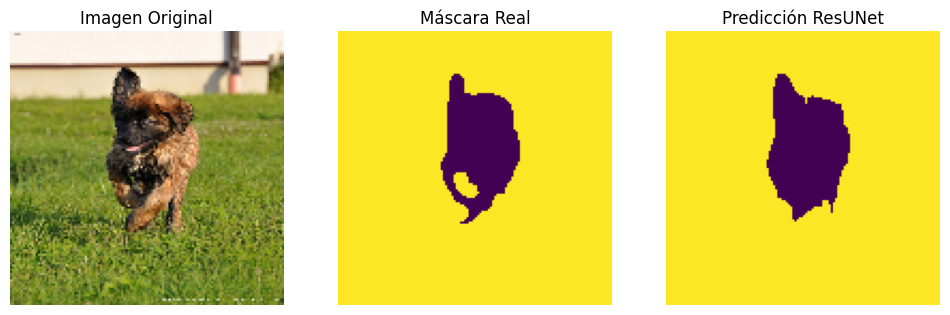

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def display(display_list):
    plt.figure(figsize=(12, 6))
    title = ['Imagen Original', 'Máscara Real', 'Predicción ResUNet']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])

        # Lógica para manejar los canales
        img_to_show = display_list[i]

        # Si tiene 2 canales (One-Hot), tomamos el argmax para tener 1 canal
        if img_to_show.shape[-1] == 2:
            img_to_show = np.argmax(img_to_show, axis=-1)

        plt.imshow(img_to_show)
        plt.axis('off')
    plt.show()

# 2. PROBAR CON EL MODELO ENTRENADO
for image, mask in val_batches.take(1):
    pred_mask = model.predict(image)

    # Tomamos el primer ejemplo del batch [0]
    # La máscara real y la predicción se procesan dentro de la función display
    display([image[0], mask[0], pred_mask[0]])